In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os
import  json
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.ensemble import RandomForestRegressor

PLOT_FOLDER = "RF_OUTPUTS"

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=9be7c98d94f69e20abfb6da3aa6ecef7ca297f1f784eb8b43ac1f493e1c19d43
  Stored in directory: /tmp/pip-ephem-wheel-cache-58benmnl/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\nP_dew statistics:")
print(df["P_dew"].describe())

Total samples: 19171

P_dew statistics:
count    19171.000000
mean        21.906458
std         17.547873
min          2.105356
25%          6.364315
50%         15.926816
75%         33.788807
max         73.568153
Name: P_dew, dtype: float64


In [3]:
target     = "P_dew"
SEED       = 8005515
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13419
Testing samples:    2876
Validation samples: 2876


Feature correlations with P_dew:
temperature           0.958140
pressure              0.845723
z_hydrogen            0.014158
z_oxygen              0.002355
z_methane             0.000058
z_carbon dioxide     -0.000940
z_argon              -0.001342
z_carbon monoxide    -0.001643
z_nitrogen           -0.002421
z_hydrogen sulfide   -0.012269
Name: P_dew, dtype: float64


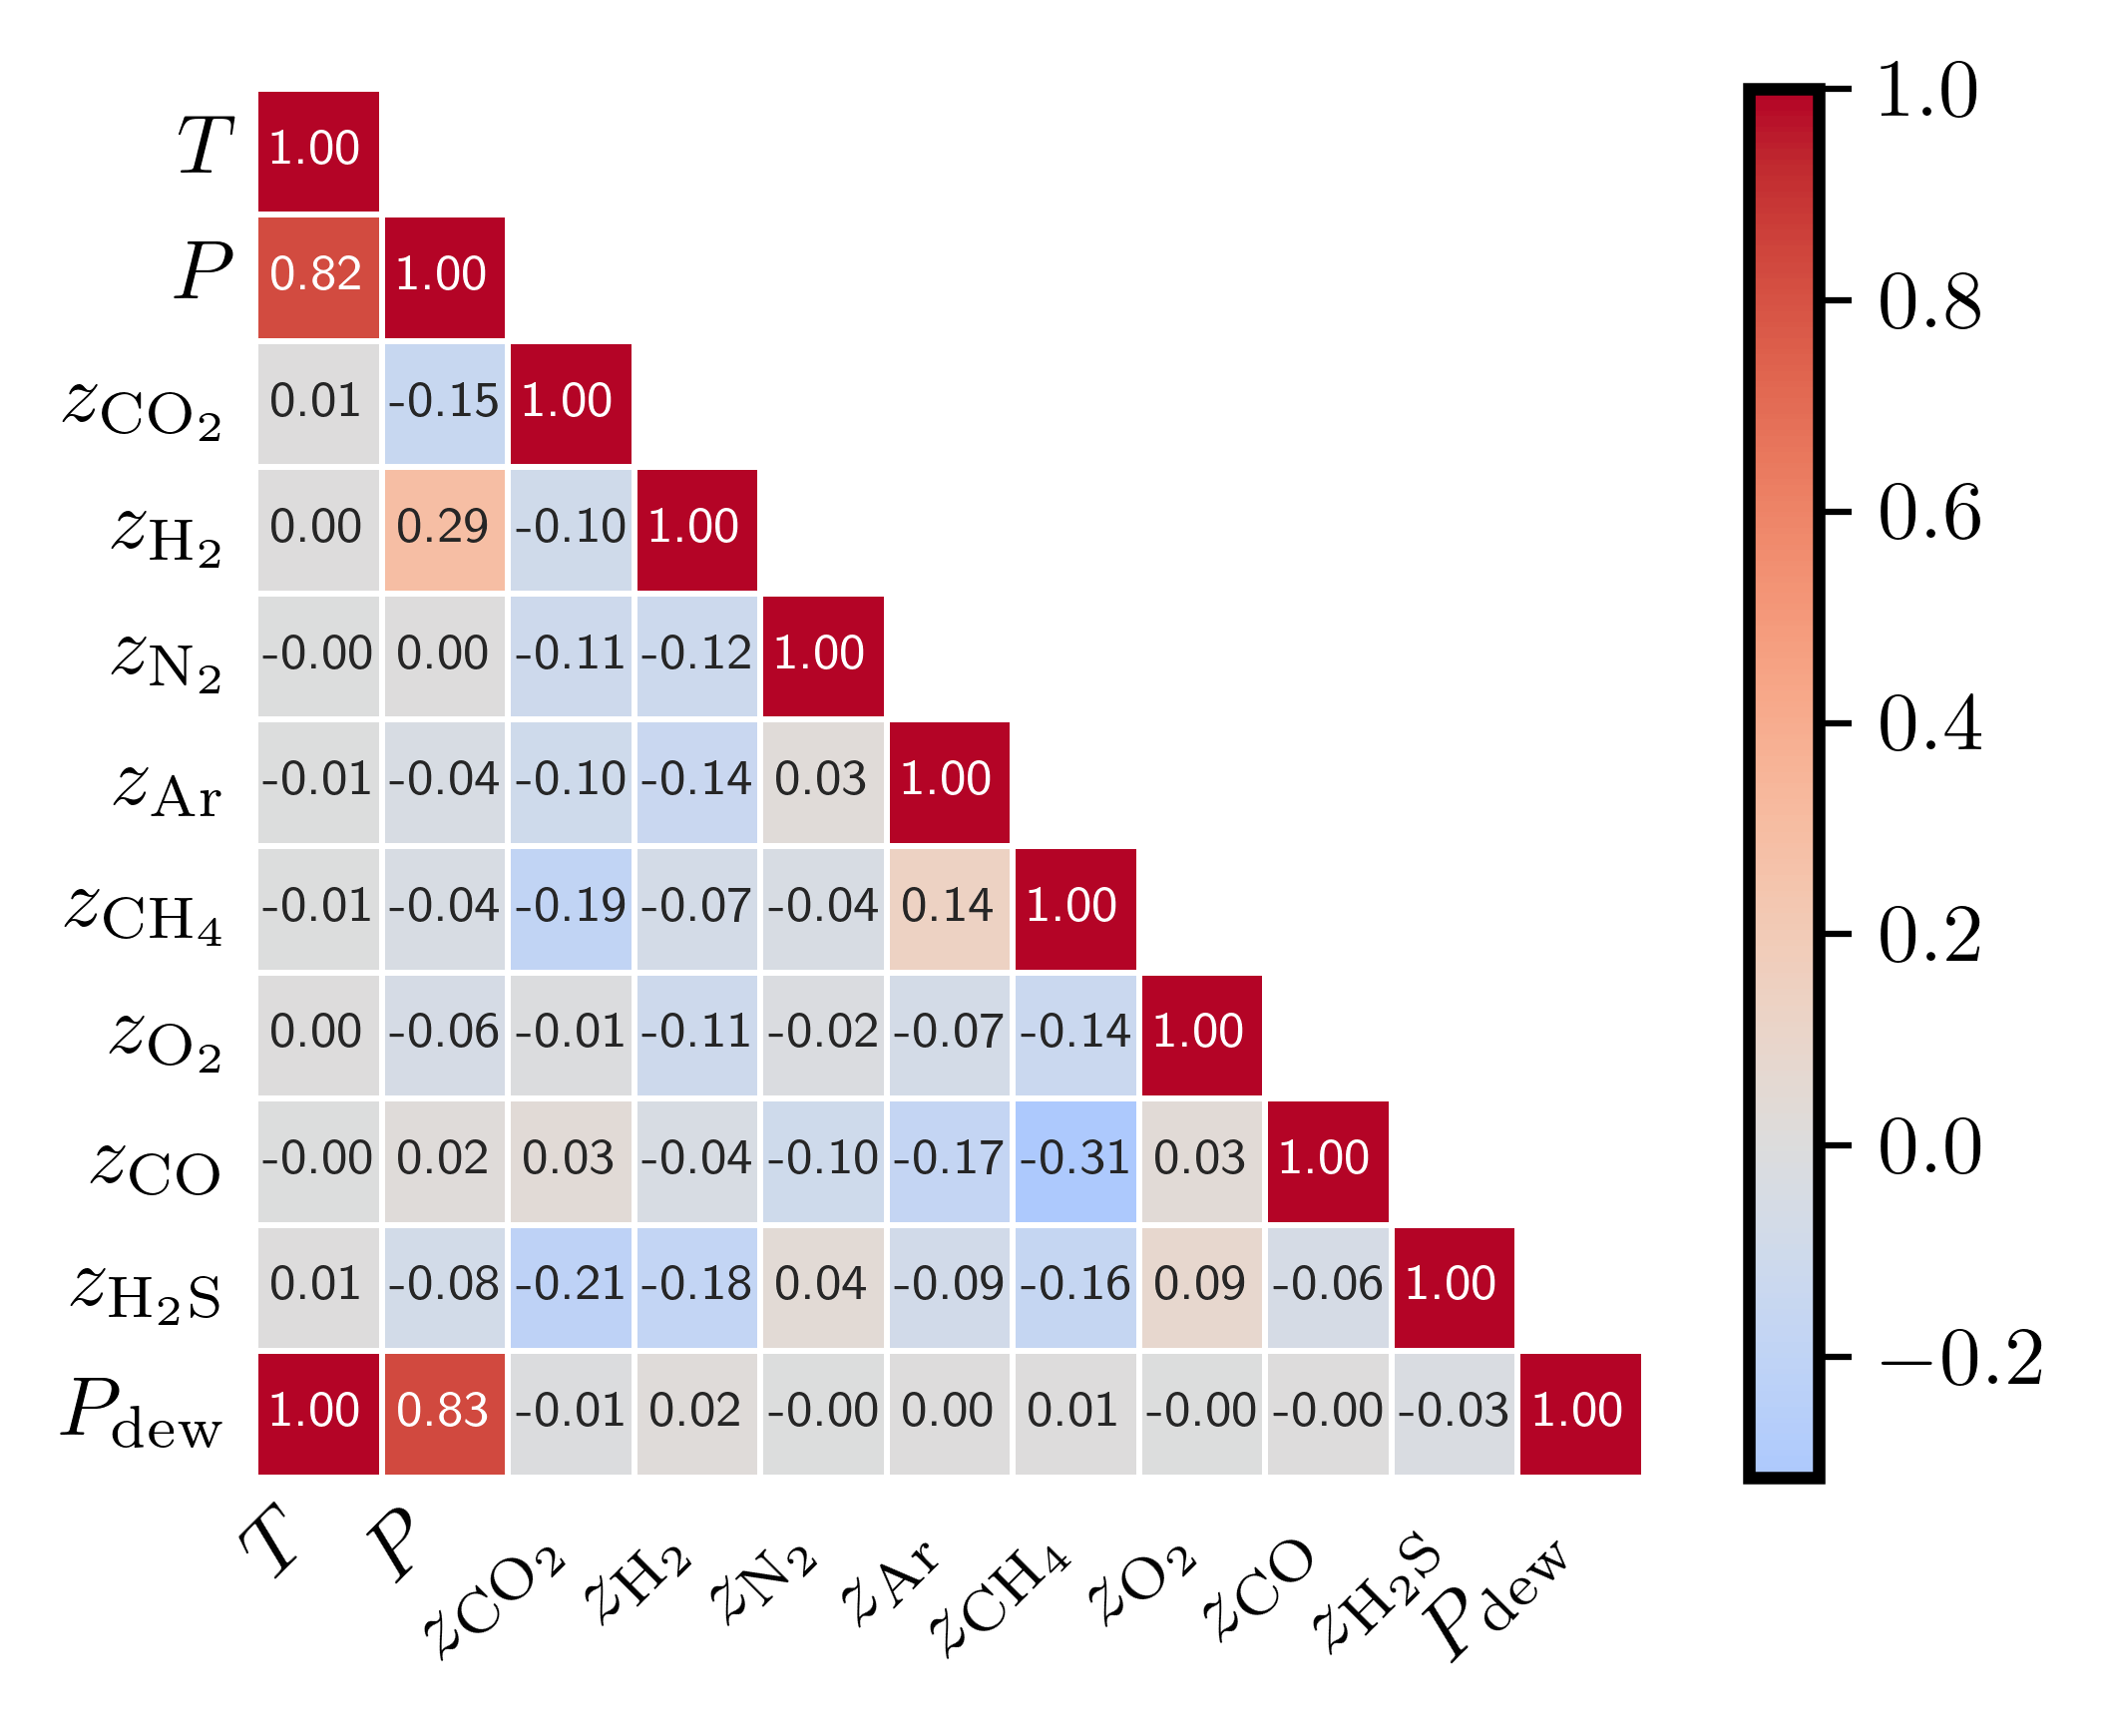

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [4]:
plot_correlation_heatmap(df, features, target, save_path="RF_P_dew_correlation", folder=PLOT_FOLDER)

In [5]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_val_pred = rf_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_dew

Training Set:
  R²:   0.999997
  RMSE: 0.031382 bar
  MAE:  0.003239 bar

Test Set:
  R²:   0.999988
  RMSE: 0.062405 bar
  MAE:  0.008566 bar

Validation Set:
  R²:   0.999992
  RMSE: 0.048490 bar
  MAE:  0.006944 bar


In [6]:
# 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R² Scores: [0.99906986 0.99990929 0.99988735 0.99987293 0.99977742]
Mean CV R²: 0.9997 (+/- 0.0006)


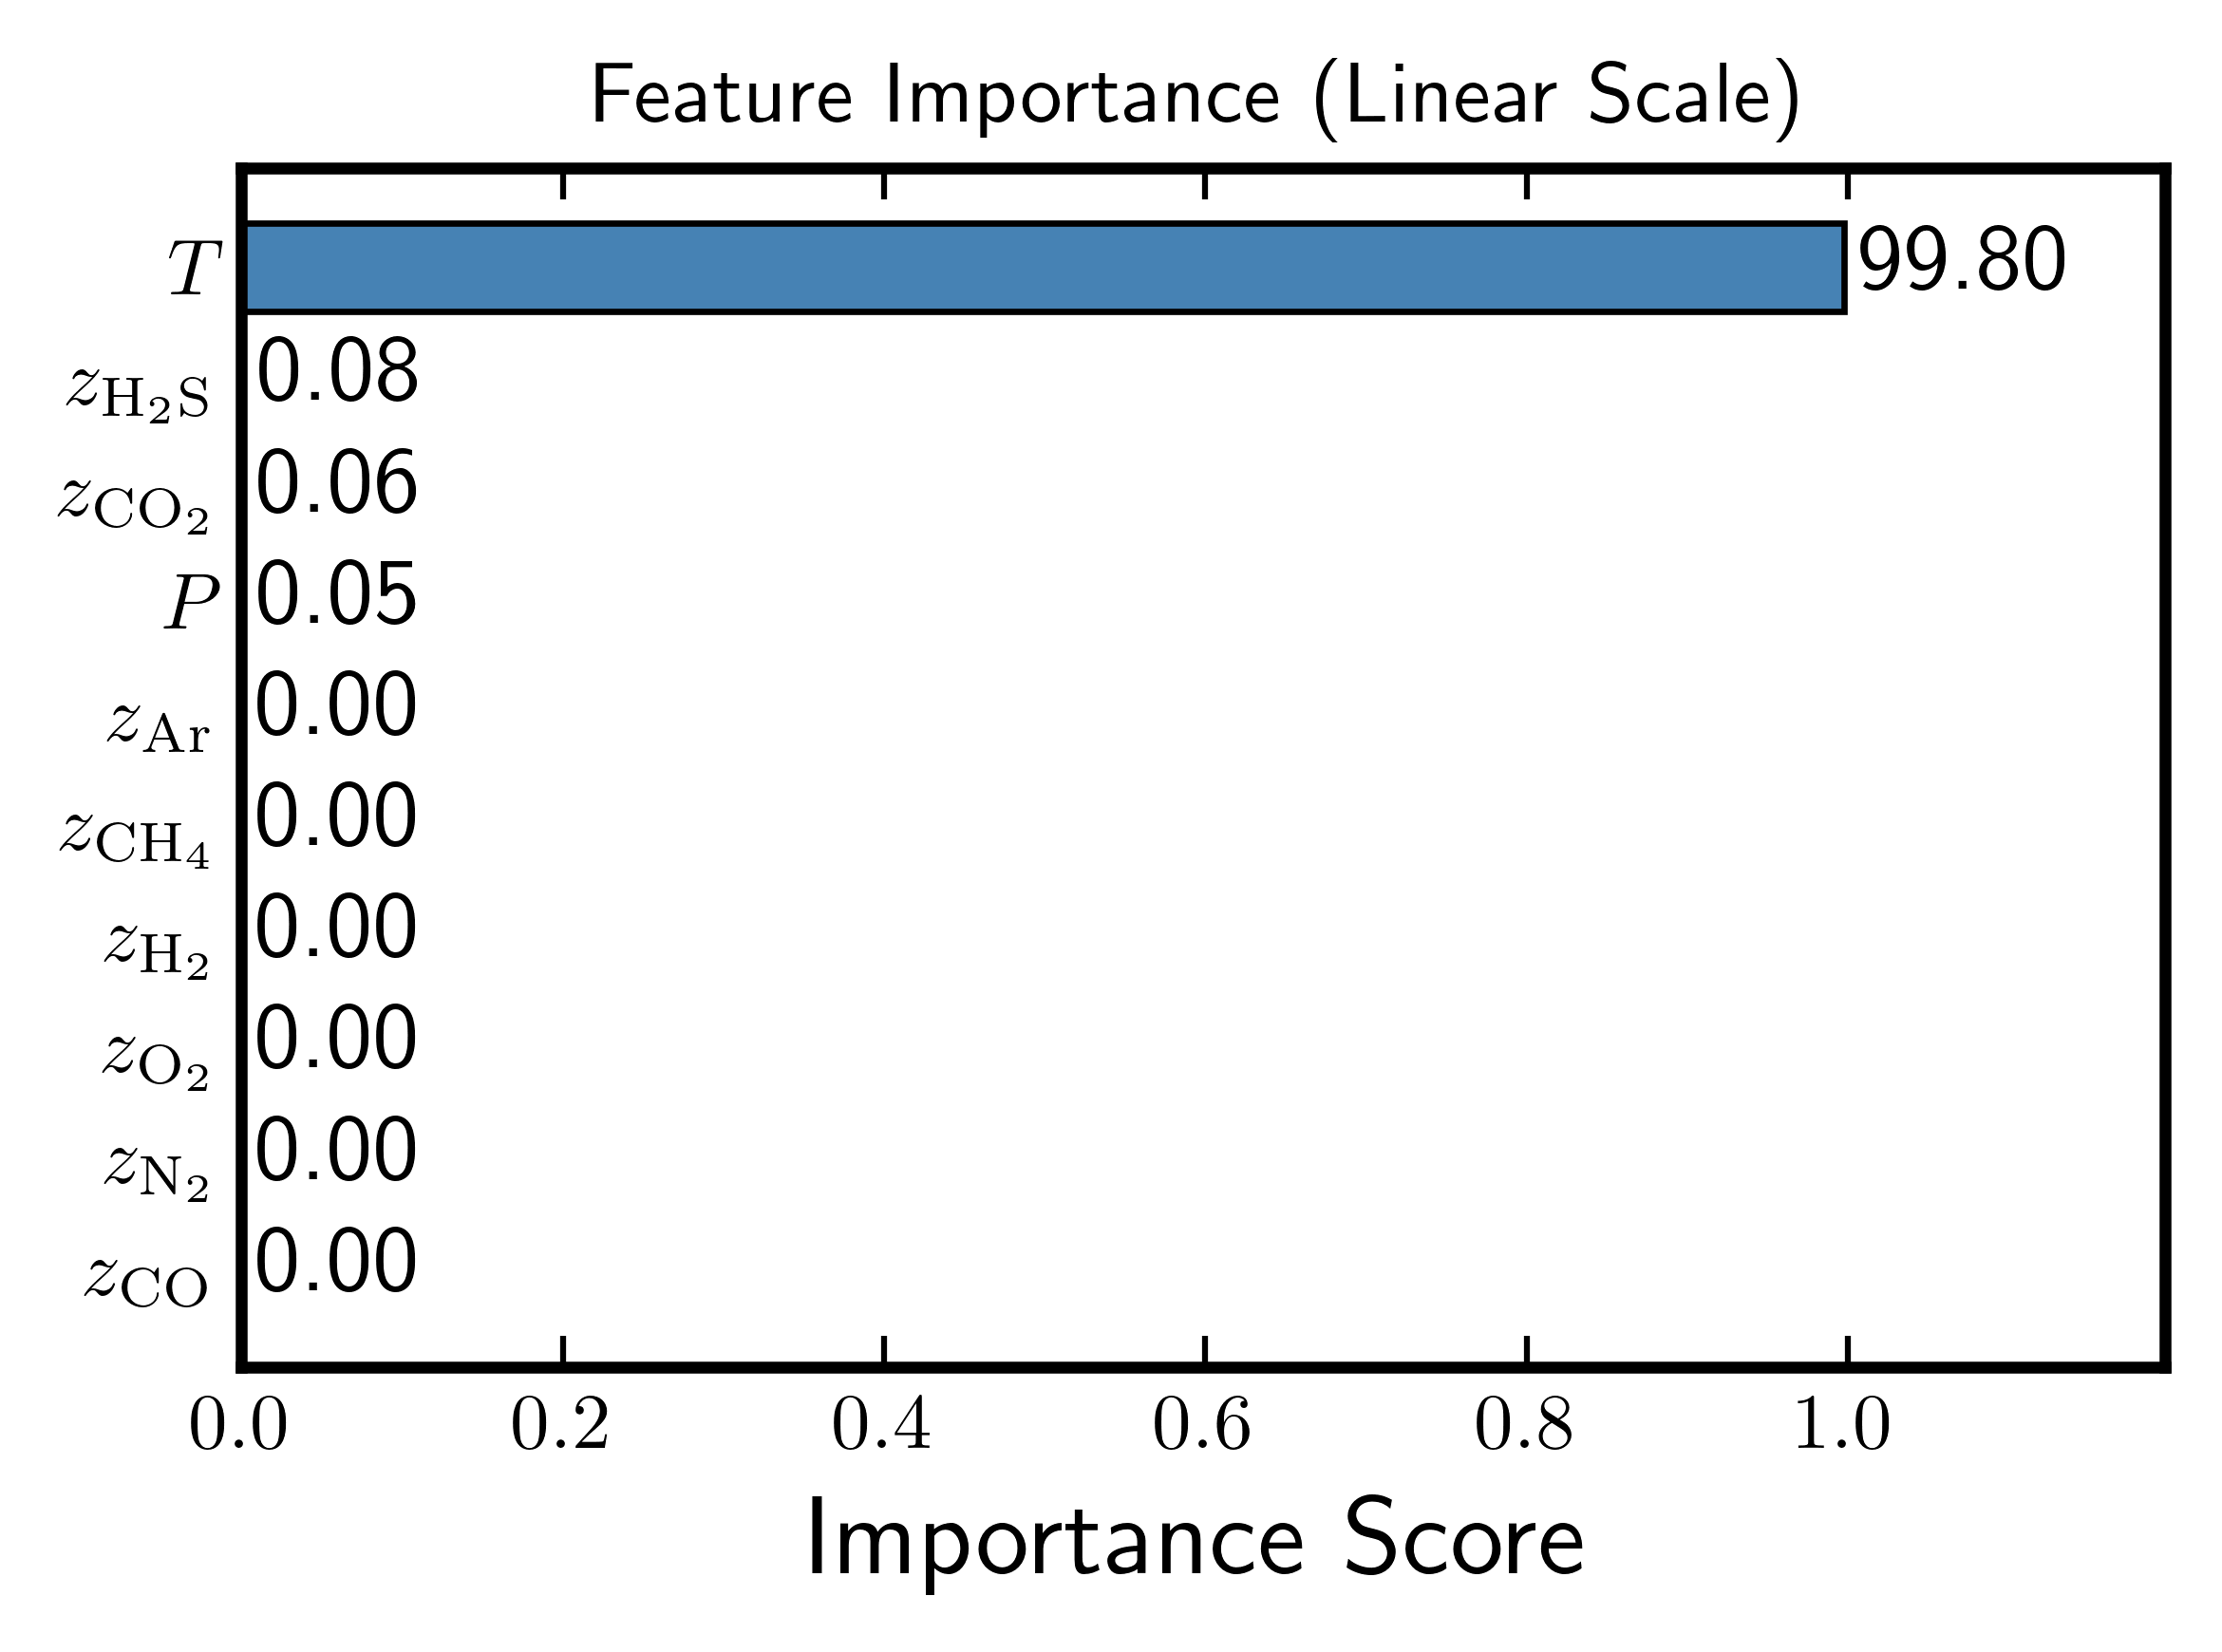

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [7]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_dew",
    feature_importances=rf_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="RF_P_dew_feature_importance_linear", folder=PLOT_FOLDER)

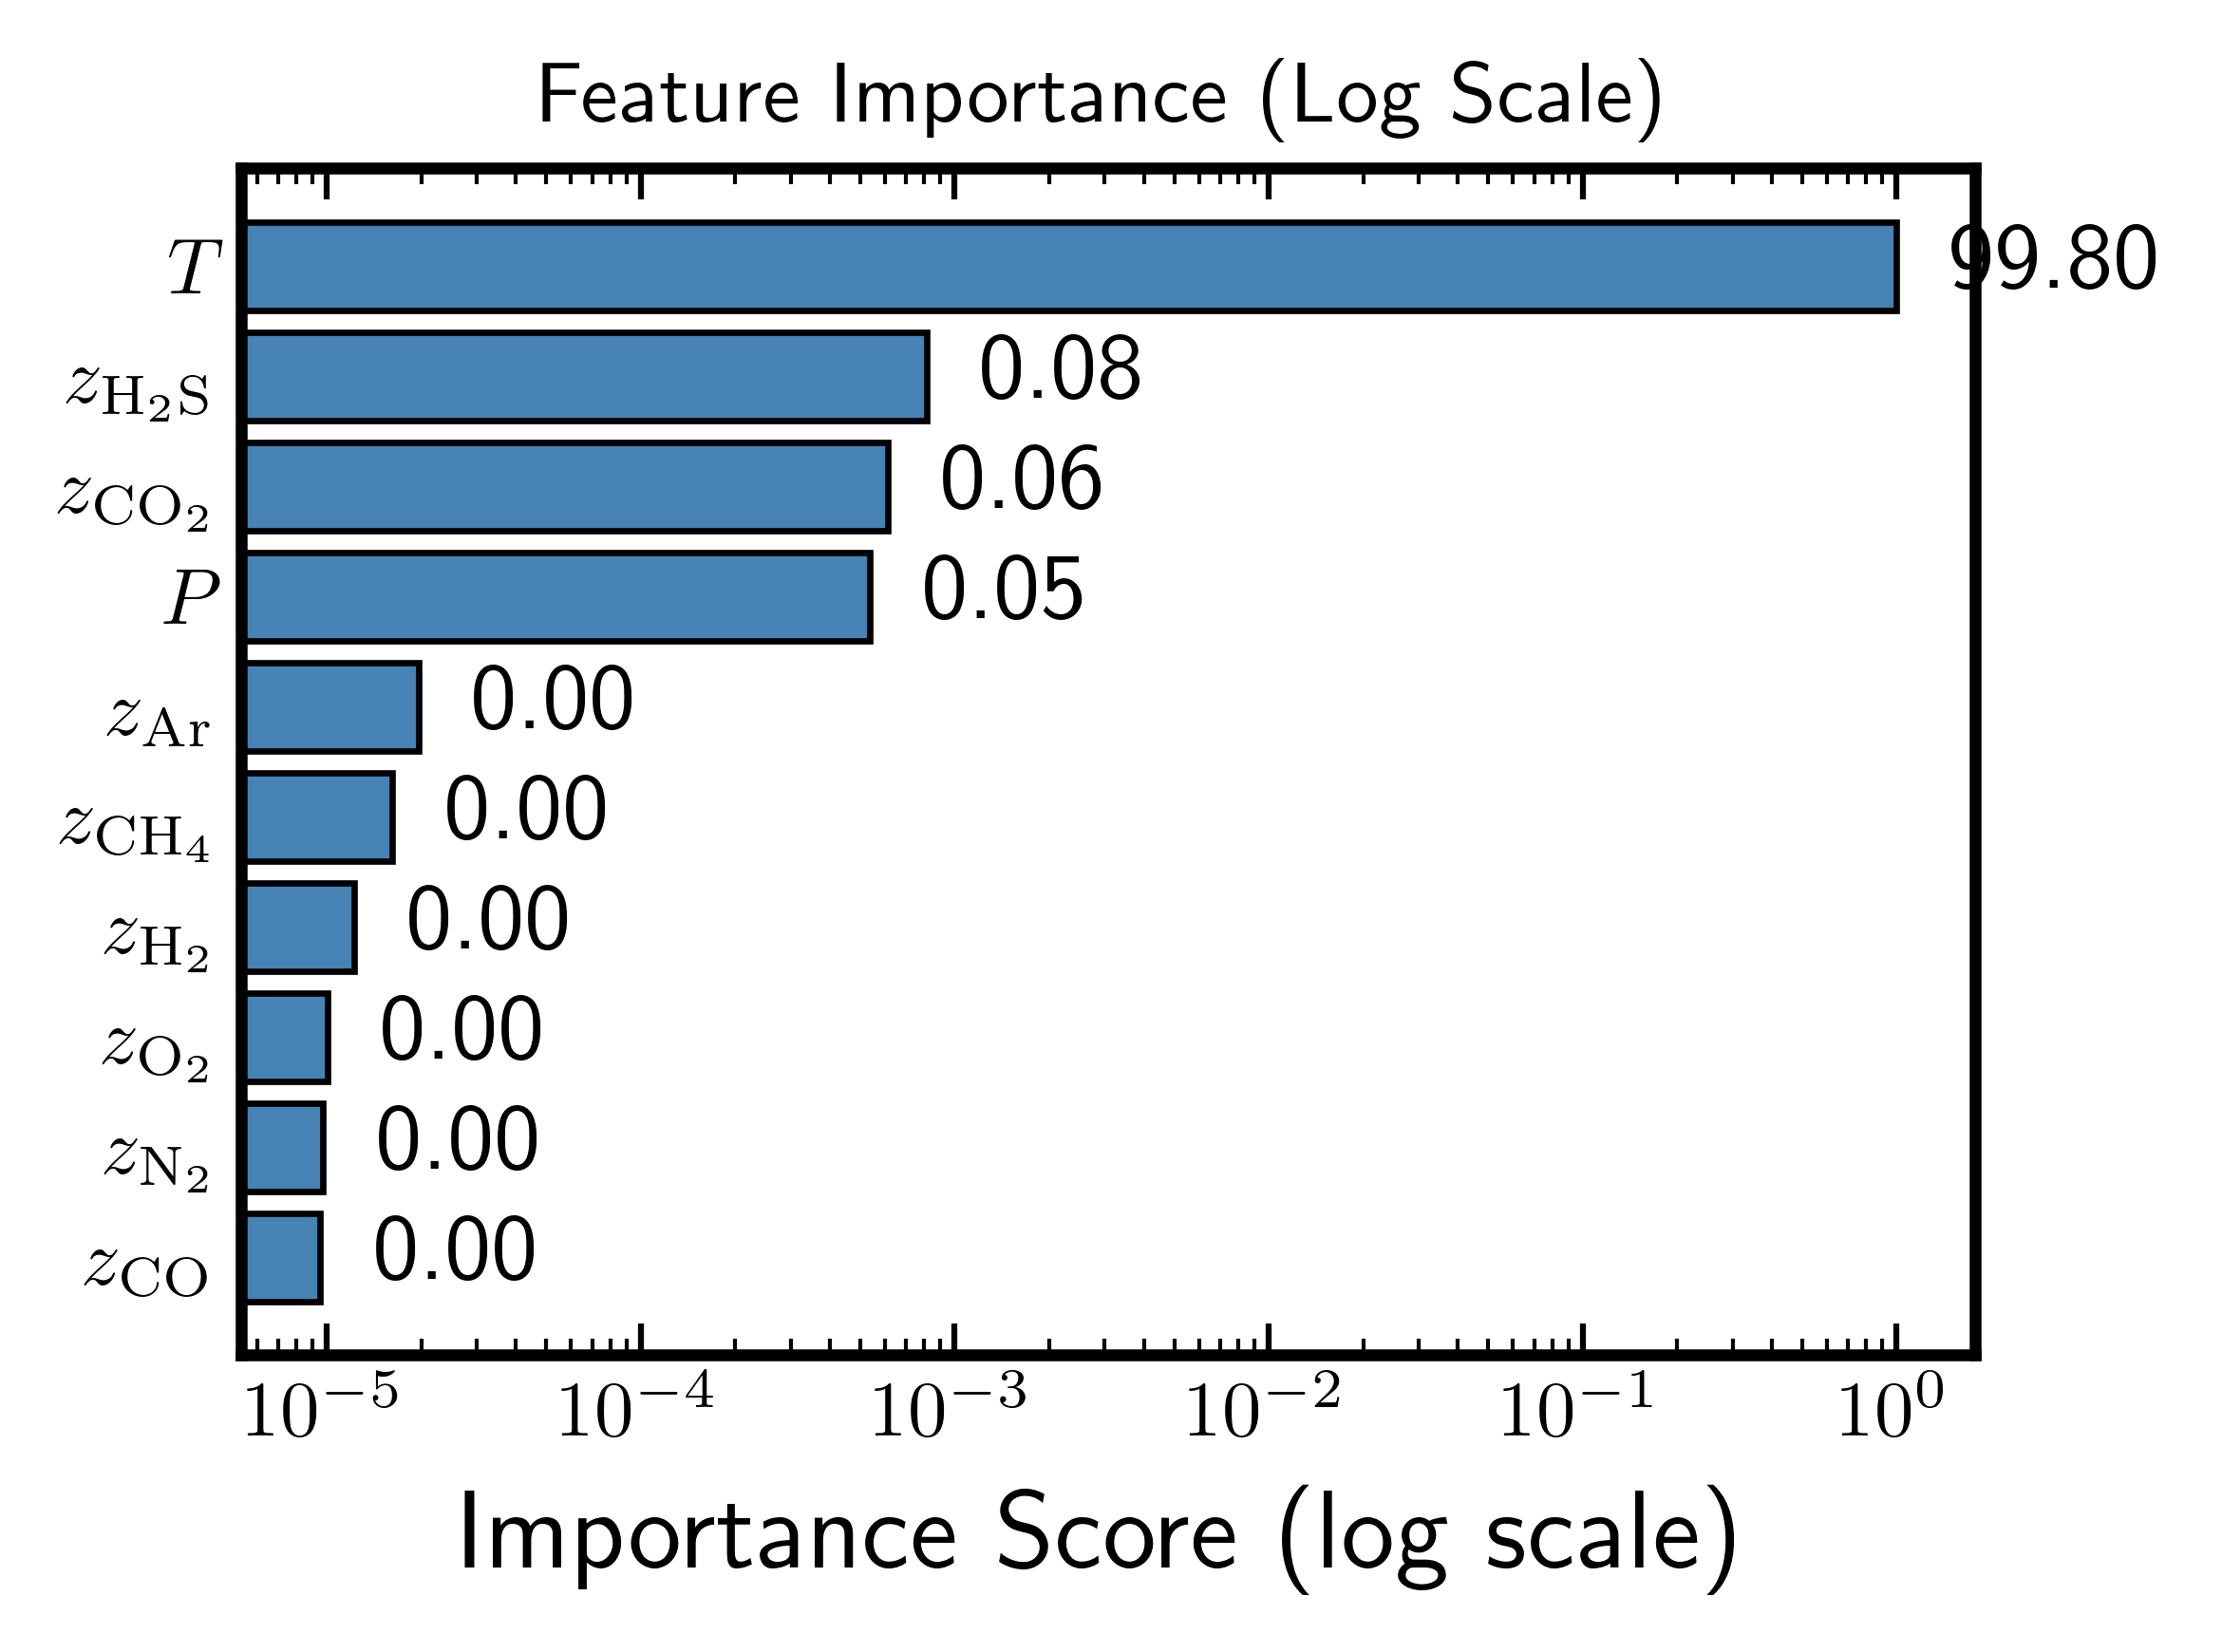

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Log Scale)'}, xlabel='Importance Score (log scale)'>)

In [8]:
# Plot feature importance (Log Scale)
post.plot_feature_importance(scale="log", save_path="RF_P_dew_feature_importance_log", folder=PLOT_FOLDER)

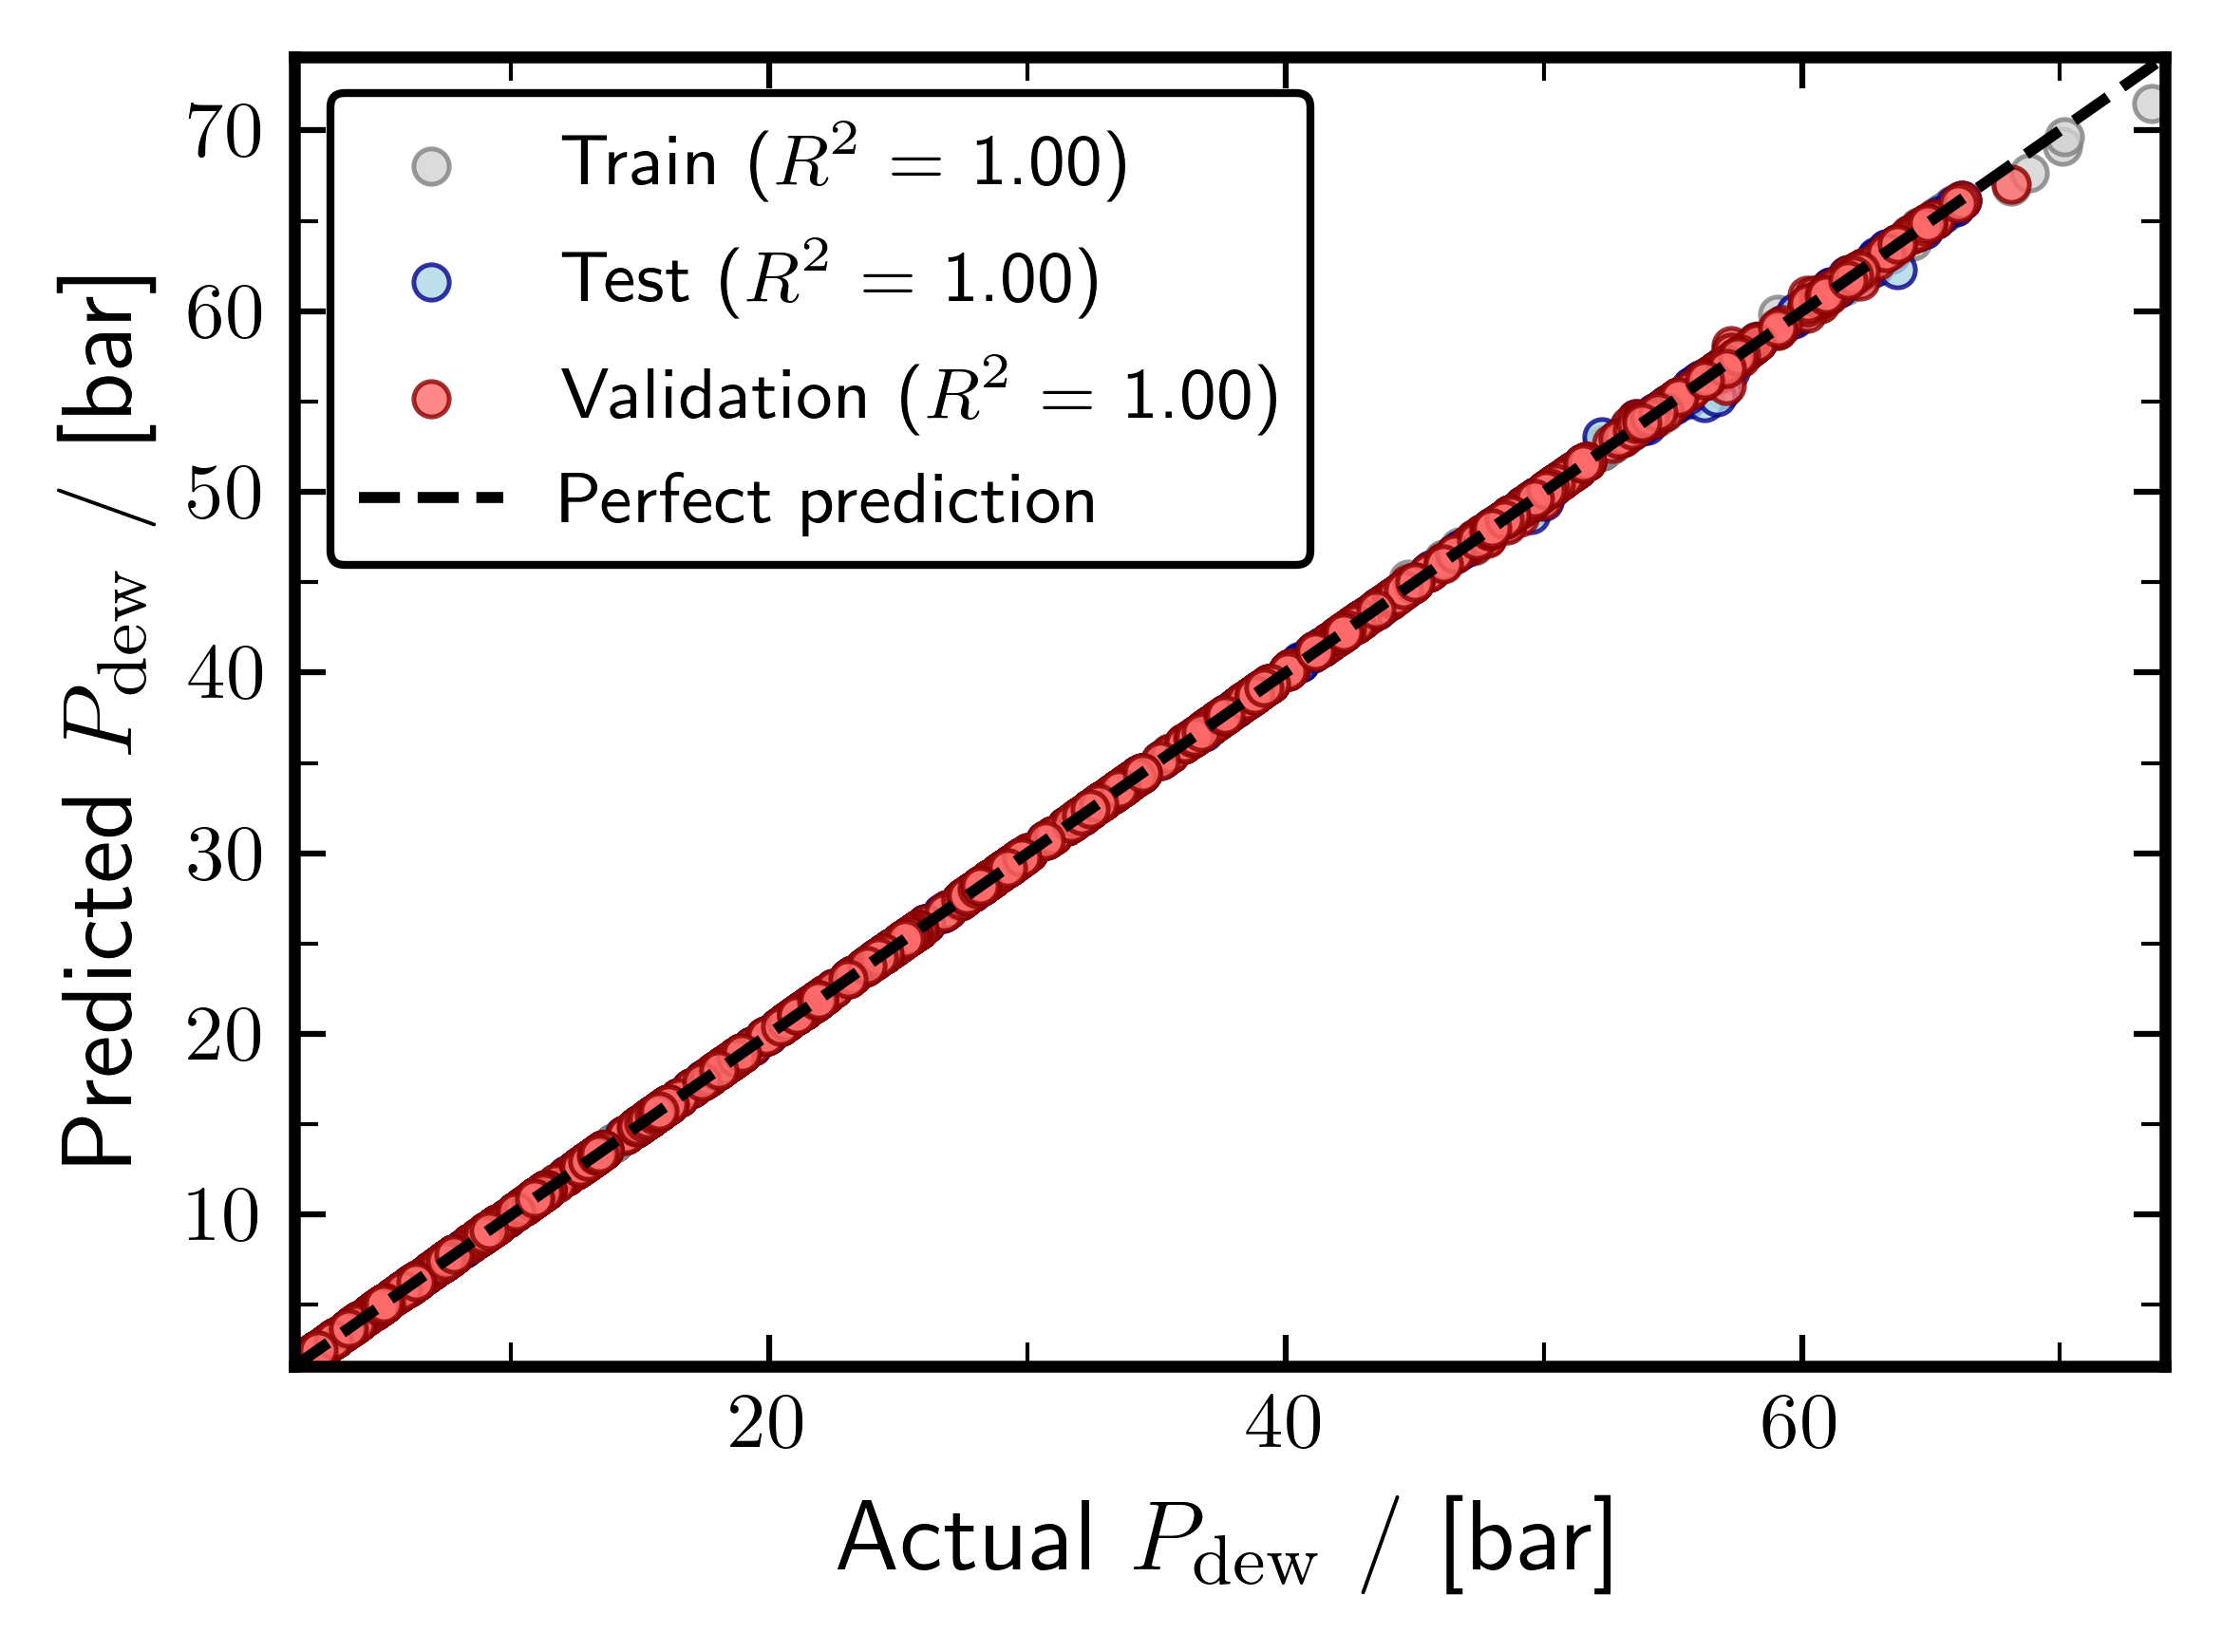

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{dew}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{dew}}$ / [bar]'>)

In [9]:
# Parity plot
post.plot_parity(model_name="Random Forest", save_path="RF_P_dew_parity_plot", folder=PLOT_FOLDER)

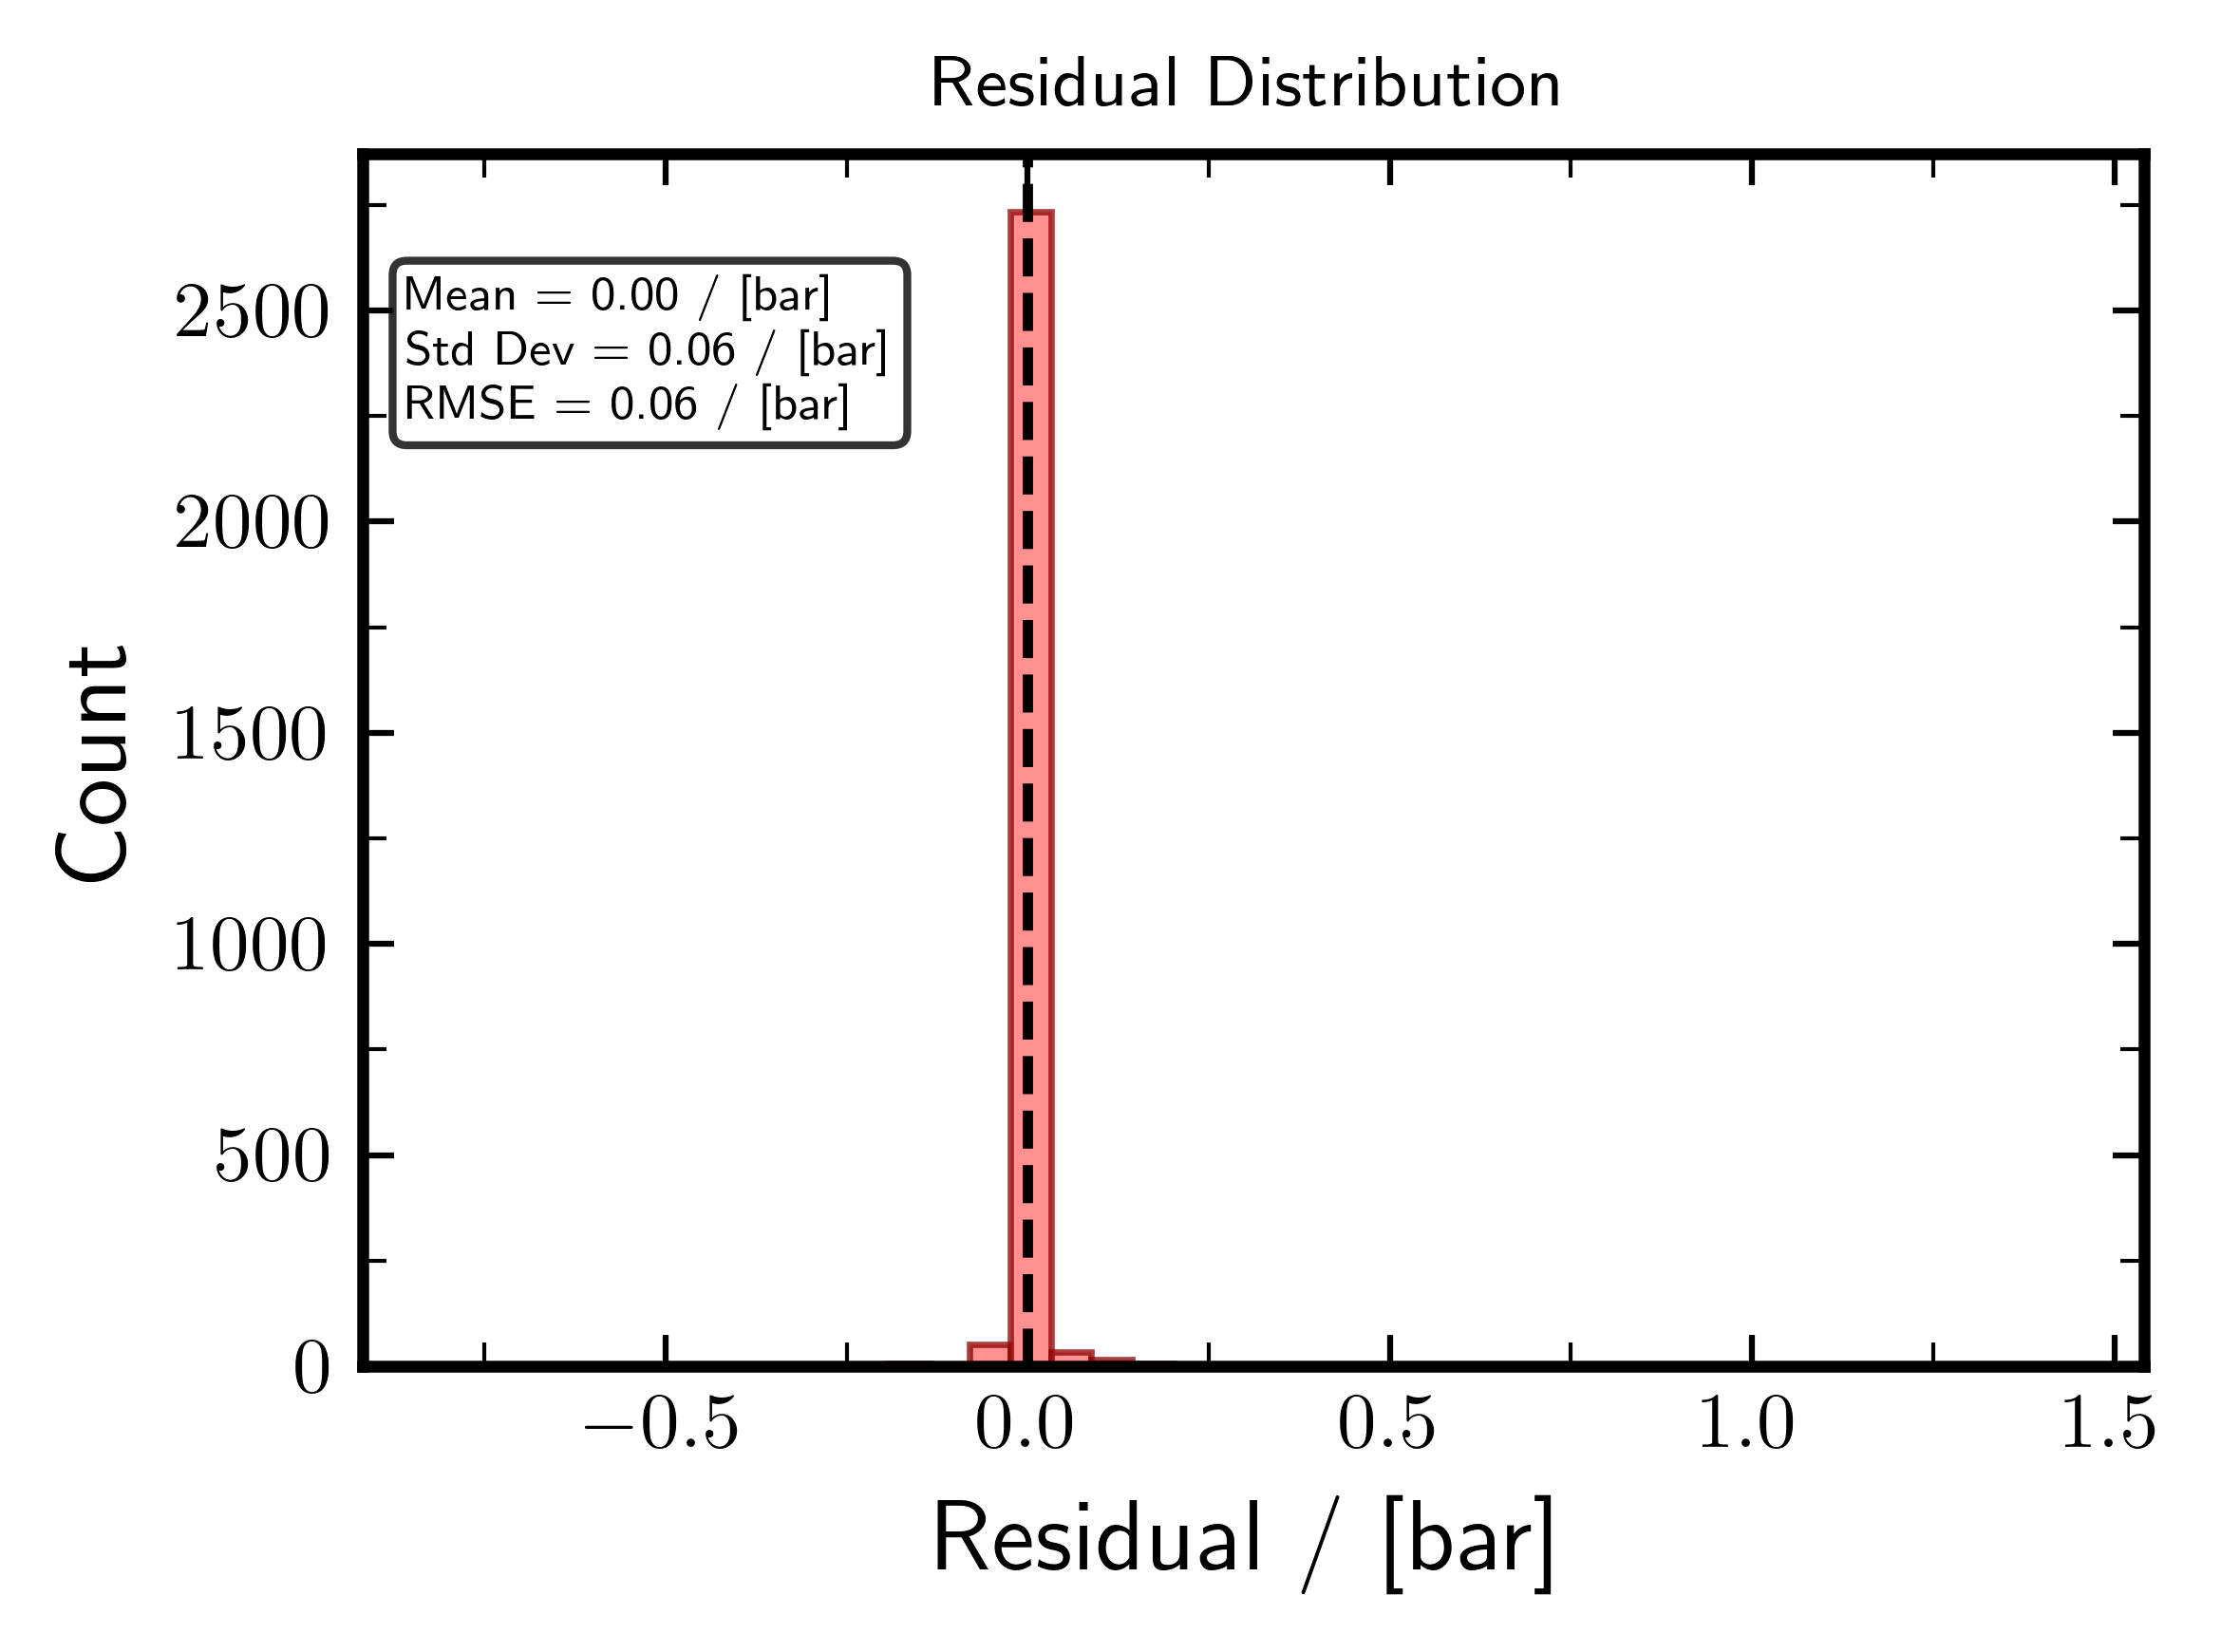

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution'}, xlabel='Residual / [bar]', ylabel='Count'>)

In [10]:
# Residual distribution
post.plot_residual_distribution(save_path="RF_P_dew_residual_distribution", folder=PLOT_FOLDER)

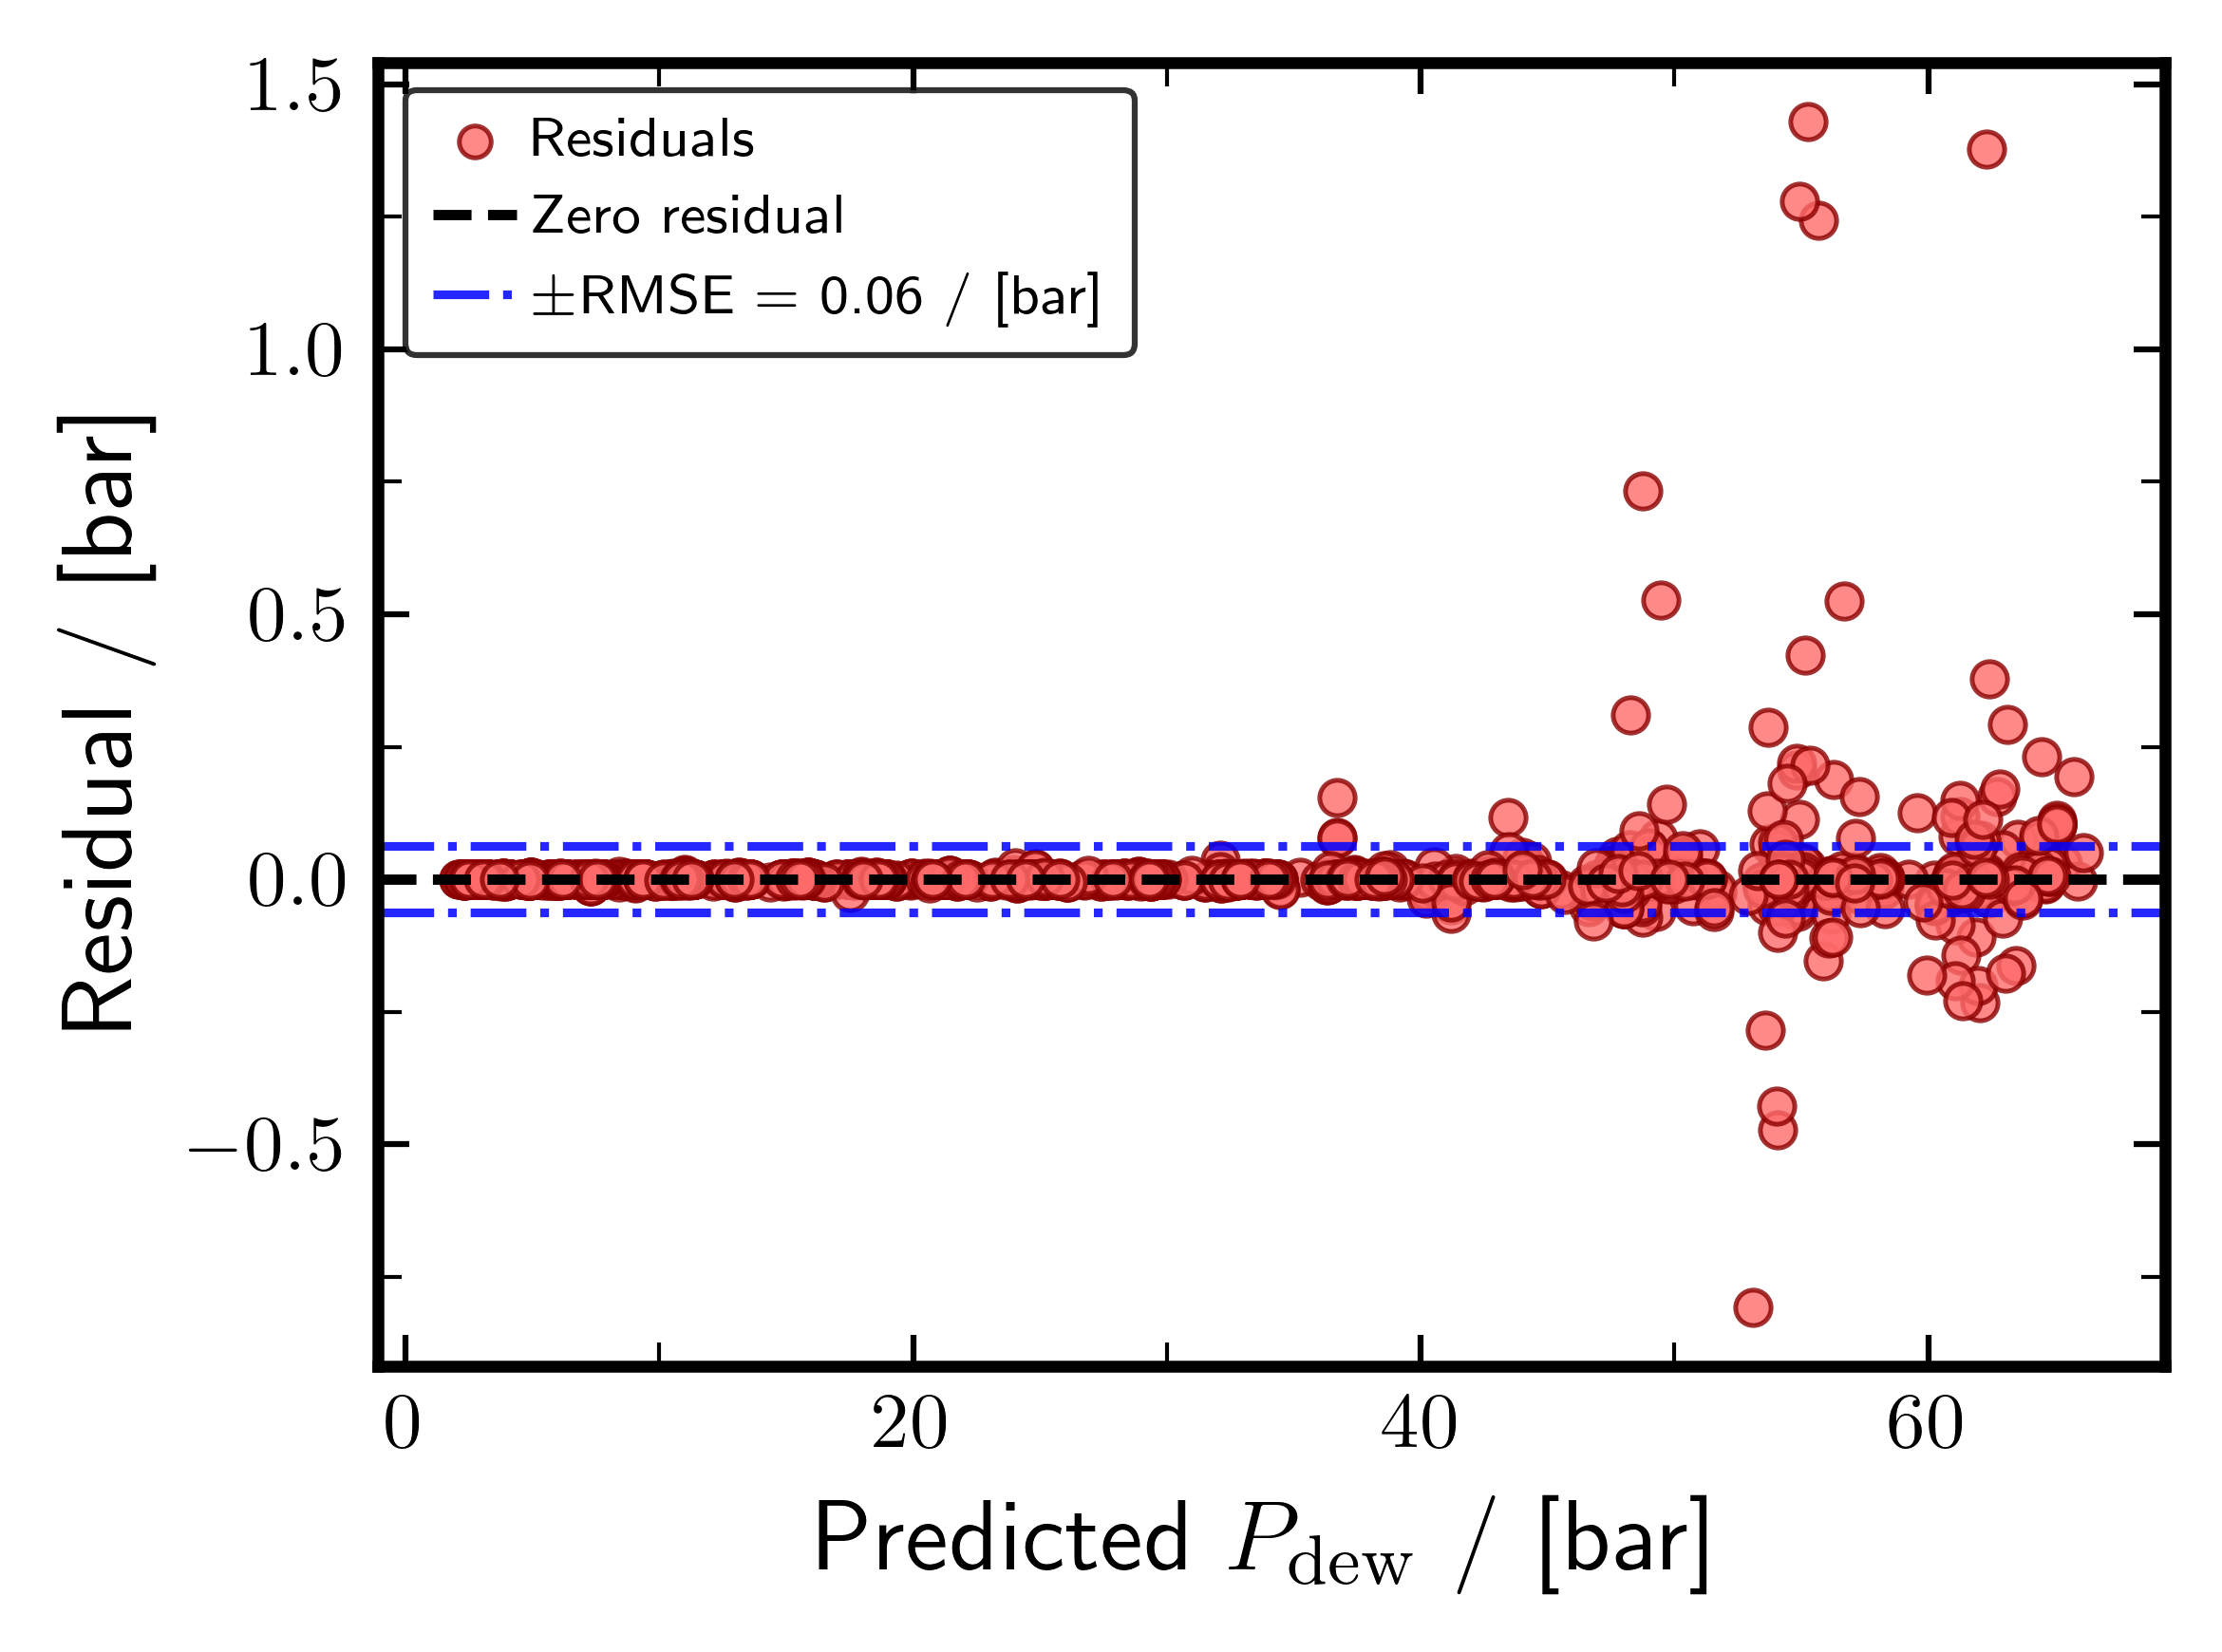

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{dew}}$ / [bar]', ylabel='Residual / [bar]'>)

In [11]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="RF_P_dew_residual_vs_predicted", folder=PLOT_FOLDER)

In [12]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]  = cv_scores.tolist()
metrics["cv_r2_mean"]    = float(cv_scores.mean())
metrics["cv_r2_std"]     = float(cv_scores.std())
metrics["model"]         = "RandomForest"
metrics["n_estimators"]  = rf_model.n_estimators
metrics["max_depth"]     = rf_model.max_depth
metrics["features"]      = features
metrics["target"]        = target
metrics["seed"]          = SEED

# Save metrics to JSON
os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_DEW
Samples:        2876
R² Score:       0.999988
RMSE:           0.062405
MAE:            0.008566
Mean Residual:  0.003025
Std Residual:   0.062331

FEATURE IMPORTANCES:
------------------------------------------------------------
  temperature               |  99.80% | █████████████████████████████████████████████████
  z_hydrogen sulfide        |   0.08% | 
  z_carbon dioxide          |   0.06% | 
  pressure                  |   0.05% | 
  z_argon                   |   0.00% | 
  z_methane                 |   0.00% | 
  z_hydrogen                |   0.00% | 
  z_oxygen                  |   0.00% | 
  z_nitrogen                |   0.00% | 
  z_carbon monoxide         |   0.00% | 

Metrics saved to: RF_OUTPUTS/RF_P_dew_metrics.json


In [13]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.73 minutes
